In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#!this libraries for model prediction
#this for splitting data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
#rate model performance and errors
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

import warnings 
warnings.filterwarnings('ignore')

In [64]:
data=pd.read_csv('house_price_data.csv')
data.head()

,Area_sqm,Rooms,Location_Score,Price_EGP
0,152,3,31.97,447000.0
1,229,5,25.15,654000.0
2,142,5,29.69,691000.0
3,64,2,60.23,383000.0
4,156,6,46.35,648000.0


In [65]:
x=data.iloc[:,:3]
y=data.iloc[:,3]


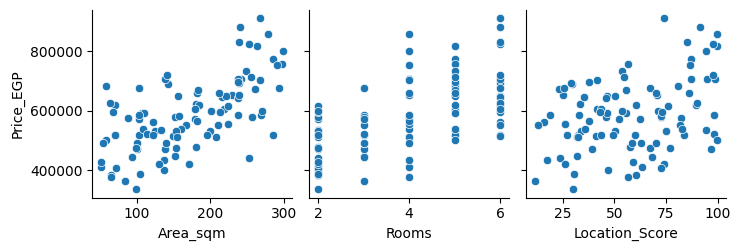

In [66]:
sns.pairplot(data,x_vars=['Area_sqm','Rooms','Location_Score'],y_vars=['Price_EGP'],kind='scatter')

In [67]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=.2,random_state=0)

In [68]:
model=LinearRegression()
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Visualization

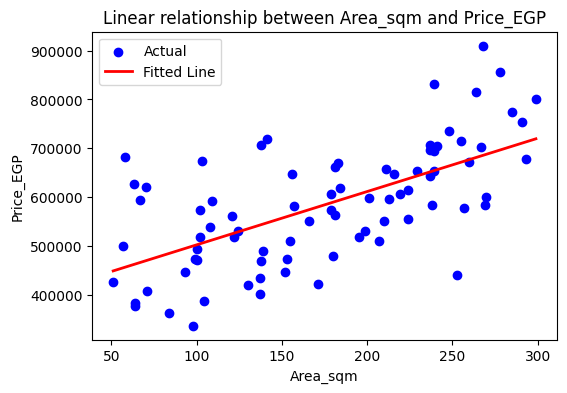

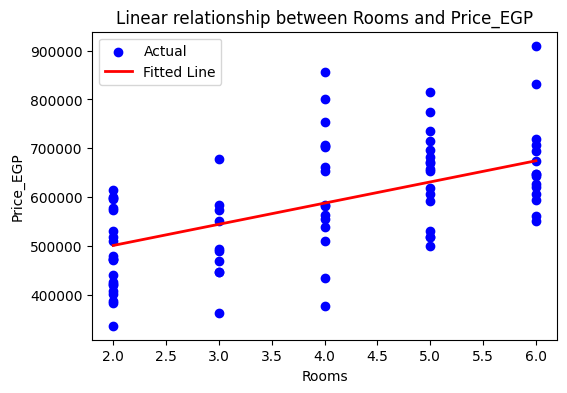

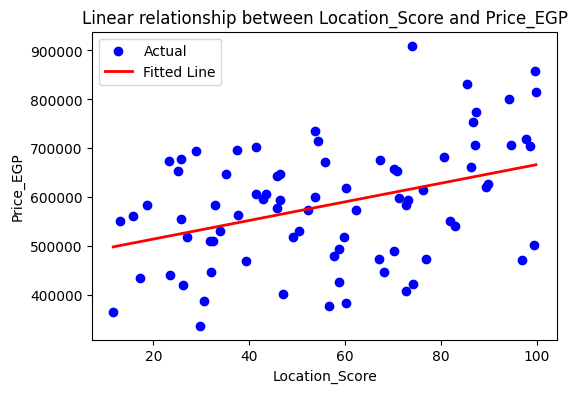

In [69]:
for col in xtrain.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(xtrain[col], ytrain, color='blue', label='Actual')
    # Plot the fitted line from the model
    x_vals = np.linspace(xtrain[col].min(), xtrain[col].max(), 100)
    # Prepare features for prediction (keep other columns at their mean)
    mean_features = xtrain.mean()
    features = np.tile(mean_features.values, (100, 1))
    col_idx = xtrain.columns.get_loc(col)
    features[:, col_idx] = x_vals
    y_pred_line = model.predict(features)
    plt.plot(x_vals, y_pred_line, color='red', linewidth=2, label='Fitted Line')
    plt.xlabel(col)
    plt.ylabel('Price_EGP')
    plt.title(f'Linear relationship between {col} and Price_EGP')
    plt.legend()
    plt.show()
    

## independence of residuals

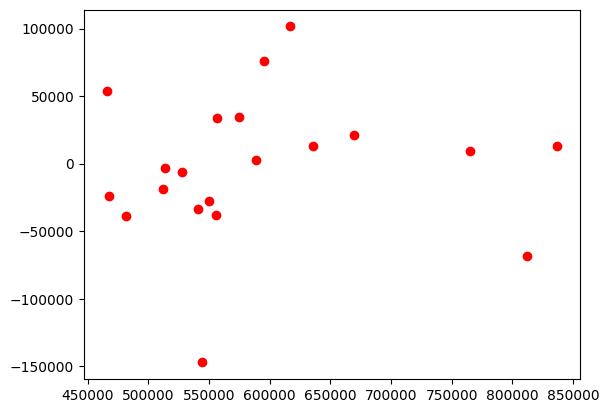

In [70]:
y_train_pred=model.predict(xtest)
error=y_train_pred-ytest
plt.scatter(y_train_pred,error,color='red')

In [71]:
r2_score(ytrain,model.predict(xtrain))

0.864717757958708

In [72]:
r2_score(ytest,model.predict(xtest))


0.7894111451701865

In [73]:
x.head(2)
# y.head(1)

,Area_sqm,Rooms,Location_Score
0,152,3,31.97
1,229,5,25.15


In [74]:
 #! this is the prediction 
predict=[[120,3,2]]
model.predict(predict)

array([380441.37222759])